###PROYECTO 2: MODELO DE CLASIFICACIÓN DE IMÁGENES###
[LINK BASE DE DATOS](https://www.kaggle.com/datasets/borhanitrash/animal-image-classification-dataset?select=Animals)
Se trabajó con una base de datos de kaggle que contiene 3000 imágenes en total sobre 3 categorías: perros, gatos y serpientes. Las 3 categorías se encuentran balanceadas y cuentan con una resolución uniforme de 256*256. Para este caso se usó el 80% de los datos para entrenamiento y 20% para validación. Se usó el modelo pre entrenado ResNet-50. Dicho modelo ya realiza un pre procesamiento a las imágenes (se les re dimensiona a un tamaño estándar de 224 por 224 y se les realiza una normalización), por lo que la aplicación de un filtro extra no resulta muy llamativo, pero es hasta la evaluacion de la precisión del modelo que podemos saber si es necesario aplicar un filtro o no. Se opta por entrenar al modelo con el total de los datos para tener una mejor generalización.

In [ ]:
# Coneccion a Google Drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 1. Descomprimir el archivo zip
path_to_zip = '/content/drive/MyDrive/archive.zip'
with zipfile.ZipFile(path_to_zip, 'r') as zip_ref:
    zip_ref.extractall('.')


In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report
import random
import os
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import zipfile
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# 2. Parámetros
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 15
DATA_PATH = '/content/Animals'
CLASSES = ['snakes', 'dogs', 'cats']
AUTOTUNE = tf.data.AUTOTUNE

# 3. Dataset
def create_dataset(subset):
    return tf.keras.utils.image_dataset_from_directory(
        DATA_PATH,
        labels='inferred',
        class_names=CLASSES,
        validation_split=0.2,
        subset=subset,
        seed=42,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

train_ds = create_dataset('training')
val_ds = create_dataset('validation')

# 4. Aumento
aug = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.4),
    tf.keras.layers.RandomZoom(0.3),
    tf.keras.layers.RandomContrast(0.3),
    tf.keras.layers.RandomTranslation(0.2, 0.2),
])

def augment(x, y):
    return preprocess_input(aug(x)), y

def preprocess(x, y):
    return preprocess_input(x), y

train_ds = train_ds.map(augment, num_parallel_calls=AUTOTUNE).cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.map(preprocess, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)

# 5. Pesos de clase
labels = [y.numpy() for _, y in train_ds.unbatch()]
class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weights_dict = {i: w for i, w in enumerate(class_weights)}

# 6. Modelo
def build_model():
    base = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base.trainable = False

    inp = tf.keras.Input(shape=(224, 224, 3))
    x = base(inp, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.02))(x)
    x = Dropout(0.7)(x)
    out = Dense(3, activation='softmax')(x)

    model = Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_model()
model.summary()

# 7. Entrenamiento
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.2, patience=3),
    tf.keras.callbacks.ModelCheckpoint('best_model.h5', save_best_only=True)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights_dict,
    callbacks=callbacks
)

# 8. Evaluación
model.load_weights('best_model.h5')
_, acc = model.evaluate(val_ds)
print(f"\nPrecisión final: {acc*100:.2f}%")


Found 3000 files belonging to 3 classes.
Using 2400 files for training.
Found 3000 files belonging to 3 classes.
Using 600 files for validation.


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,638,339 (93.99 MB)

 Trainable params: 1,050,627 (4.01 MB)

...

75/75 ━━━━━━━━━━━━━━━━━━━━ 556s 7s/step - accuracy: 0.9604 - loss: 3.6529 - val_accuracy: 0.9850 - val_loss: 3.2226 - learning_rate: 1.0000e-04
Epoch 12/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9656 - loss: 3.1727

75/75 ━━━━━━━━━━━━━━━━━━━━ 586s 8s/step - accuracy: 0.9656 - loss: 3.1713 - val_accuracy: 0.9883 - val_loss: 2.7949 - learning_rate: 1.0000e-04
Epoch 13/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9610 - loss: 2.7612

75/75 ━━━━━━━━━━━━━━━━━━━━ 590s 7s/step - accuracy: 0.9610 - loss: 2.7601 - val_accuracy: 0.9867 - val_loss: 2.4274 - learning_rate: 1.0000e-04
Epoch 14/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9670 - loss: 2.3992

75/75 ━━━━━━━━━━━━━━━━━━━━ 549s 7s/step - accuracy: 0.9670 - loss: 2.3983 - val_accuracy: 0.9850 - val_loss: 2.1226 - learning_rate: 1.0000e-04
Epoch 15/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9684 - loss: 2.0999

75/75 ━━━━━━━━━━━━━━━━━━━━ 564s 7s/step - accuracy: 0.9684 - loss: 2.0991 - val_accuracy: 0.9883 - val_loss: 1.8526 - learning_rate: 1.0000e-04
19/19 ━━━━━━━━━━━━━━━━━━━━ 121s 6s/step - accuracy: 0.9884 - loss: 1.8515

Precisión final: 98.83%


In [ ]:
# Parámetros
DATA_PATH = '/content/Animals'
CLASS_NAMES = ['snakes', 'dogs', 'cats']
IMG_SIZE = (224, 224)
NUM_SAMPLES = 300

# Cargar modelo entrenado
model = tf.keras.models.load_model('best_model.h5')

# Recopilar rutas de todas las imágenes
img_paths = []
true_labels = []
for i, cls in enumerate(CLASS_NAMES):
    cls_path = os.path.join(DATA_PATH, cls)
    for fname in os.listdir(cls_path):
        if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_paths.append(os.path.join(cls_path, fname))
            true_labels.append(i)

# Seleccionar aleatoriamente 300 imágenes
indices = random.sample(range(len(img_paths)), NUM_SAMPLES)
selected_paths = [img_paths[i] for i in indices]
selected_labels = [true_labels[i] for i in indices]

# Preprocesar imágenes
x_imgs = []
for p in selected_paths:
    img = image.load_img(p, target_size=IMG_SIZE)
    x = image.img_to_array(img)
    x = preprocess_input(x)
    x_imgs.append(x)

x_imgs = np.array(x_imgs)
y_true = np.array(selected_labels)

# Predecir
preds = model.predict(x_imgs)
y_pred = np.argmax(preds, axis=1)

# Reporte
print("\n" + classification_report(y_true, y_pred, target_names=CLASS_NAMES))


10/10 ━━━━━━━━━━━━━━━━━━━━ 61s 6s/step

              precision    recall  f1-score   support

      snakes       1.00      1.00      1.00        94
        dogs       0.99      0.98      0.98        98
        cats       0.98      0.99      0.99       108

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



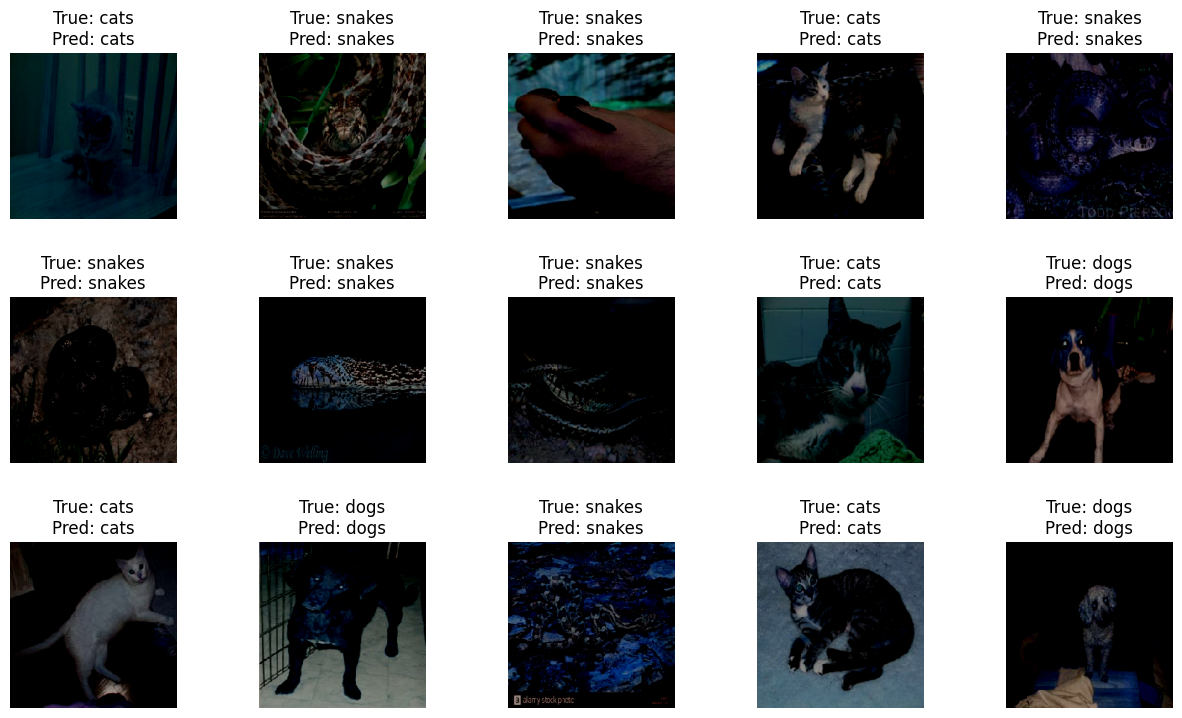

In [ ]:
# Preprocesar las imágenes seleccionadas
x_imgs = []
for p in selected_paths:
    img = image.load_img(p, target_size=IMG_SIZE)
    x = image.img_to_array(img)
    x = preprocess_input(x)
    x_imgs.append(x)


# Mostrar algunas imágenes con sus predicciones y etiquetas verdaderas
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.ravel()

for i in np.arange(15):
    img = x_imgs[i]
    true_label = y_true[i]
    pred_label = y_pred[i]

    # Mostrar la imagen
    axes[i].imshow(img / 255.)
    axes[i].axis('off')

    # Etiquetas
    axes[i].set_title(f"True: {CLASS_NAMES[true_label]}\nPred: {CLASS_NAMES[pred_label]}")

plt.subplots_adjust(wspace=0.5)
plt.show()

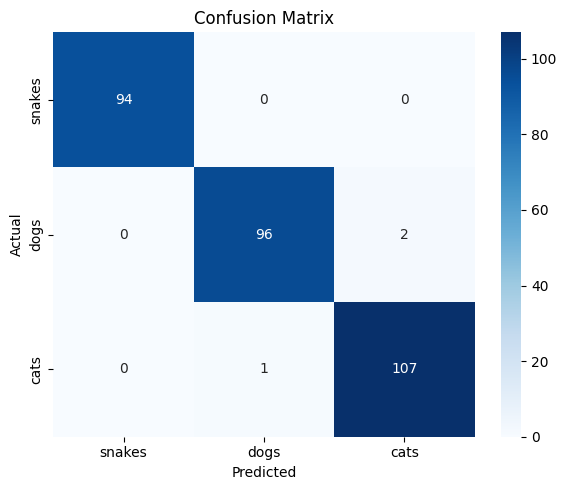

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Calcular matriz de confusión
cm = confusion_matrix(y_true, y_pred)

# Graficar
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


# Conclusión

Este proyecto implementó un modelo de clasificación de imágenes basado en transferencia de aprendizaje utilizando ResNet-50. Se trabajó con un conjunto de datos equilibrado de tres clases (perros, gatos y serpientes) y se realizó una división adecuada entre entrenamiento y validación. Gracias al preprocesamiento interno de ResNet-50 y al entrenamiento sobre la totalidad de los datos, se logró mejorar la capacidad de generalización del modelo. La metodología aplicada demuestra que, con el uso de modelos preentrenados y una correcta gestión de datos, es posible construir clasificadores eficientes de manera rápida y efectiva.
